# Notebook 3 — Building the Connectome Graph with NetworkX

**BINFX410 · Chapter 10 · Connectomics**

---

## Learning Objectives

1. Assign detected synapses to pre- and post-synaptic neuron pairs using nearest-neighbor matching
2. Construct a directed weighted graph of the connectome using NetworkX
3. Compute and interpret graph-theoretic metrics: degree distribution, clustering coefficient, shortest paths, centrality
4. Visualize the connectome graph with anatomically meaningful layouts
5. Identify hub neurons and compare the detected connectome with ground truth

---

## Background

A **connectome** is naturally represented as a directed graph $G = (V, E)$ where:
- Each **node** $v_i \in V$ is a neuron
- Each **directed edge** $(v_i \to v_j) \in E$ represents a synaptic projection from neuron $i$ to neuron $j$
- Edge **weight** encodes connection strength (e.g., synapse count, proximity)

Real connectomes (e.g., *C. elegans*) exhibit small-world and scale-free network properties: most neurons have few connections, but a small number of hub neurons are highly connected. Understanding these topological features is key to understanding information flow in neural circuits.

### From pixels to graph edges

The output of Notebook 2 gives us:
1. A list of **soma centroids** (candidate neuron locations)
2. A list of **synapse centroids** (candidate connection points)

We now need to decide: *which neuron is the pre-synaptic sender, and which is the post-synaptic receiver?*

Our heuristic: the **closest soma** to a synapse terminal is the post-synaptic neuron (receiver), and the soma whose axon is most likely to have generated that terminal is the pre-synaptic neuron. Since we do not have axon tracing here, we use the **second-closest soma** as the pre-synaptic neuron — a simplification that works well for our synthetic data.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import networkx as nx

DATA_DIR = Path('../data')

with open(DATA_DIR / 'segmentation_results.pkl', 'rb') as f:
    seg = pickle.load(f)

detected_soma     = seg['detected_soma']      # list of (r, c) tuples
detected_synapses = seg['detected_synapses']  # list of (r, c) tuples
gt_neurons        = seg['gt_neurons']
gt_synapses       = seg['gt_synapses']
image             = seg['image']

print(f'Detected soma     : {len(detected_soma)}')
print(f'Detected synapses : {len(detected_synapses)}')
print(f'GT neurons        : {len(gt_neurons)}')
print(f'GT synapses       : {len(gt_synapses)}')

Detected soma     : 11
Detected synapses : 47
GT neurons        : 8
GT synapses       : 7


## 1. Assign Synapses to Neuron Pairs

In [2]:
def assign_synapses_to_neurons(soma_centroids, synapse_centroids, max_dist=80.0):
    """
    For each synapse, find the two closest soma.
    Return (pre_id, post_id, synapse_location, distance_to_post).
    
    Convention: closest soma = post-synaptic (receiver)
                second-closest = pre-synaptic (sender)
    """
    soma_arr = np.array(soma_centroids)  # (N, 2)
    edges = []

    for syn in synapse_centroids:
        syn_arr = np.array(syn)
        dists   = np.linalg.norm(soma_arr - syn_arr, axis=1)
        order   = np.argsort(dists)

        if len(order) < 2:
            continue

        post_id = int(order[0])
        pre_id  = int(order[1])
        dist    = float(dists[order[0]])

        if dist < max_dist:
            edges.append({
                'pre_id'   : pre_id,
                'post_id'  : post_id,
                'syn_r'    : syn[0],
                'syn_c'    : syn[1],
                'dist'     : dist,
            })

    return edges


detected_edges = assign_synapses_to_neurons(detected_soma, detected_synapses)
print(f'Assigned {len(detected_edges)} synaptic edges')

edge_df = pd.DataFrame(detected_edges)
print(edge_df.head(10).to_string(index=False))

Assigned 42 synaptic edges
 pre_id  post_id      syn_r      syn_c      dist
      8        9 380.188898 129.110191 38.367710
      5        0  72.655172 435.919540 24.698233
      5        0  83.200000 461.700000 23.445844
      4        1  97.213793 212.103448 27.636820
      3        1  83.426471 240.220588 27.330683
      5        0  99.439024 418.975610 23.595095
      5        0  96.276923 487.030769 44.645363
      3        1 111.363636 269.909091 33.573335
      6        2 120.572464  56.086957 18.402055
      6        2 158.000000  37.805556 31.302028


## 2. Build the NetworkX Graph

In [3]:
def build_connectome_graph(soma_centroids, edges):
    """
    Build a directed weighted graph from soma centroids and assigned edges.
    Multiple synapses between the same pair accumulate as edge weight.
    """
    G = nx.DiGraph()

    # Add nodes with spatial attributes
    for i, (r, c) in enumerate(soma_centroids):
        G.add_node(i, pos=(c, -r),  # (x, y) — flip r for display
                   row=r, col=c,
                   label=f'N{i}')

    # Add edges; accumulate weights for repeated connections
    for e in edges:
        u, v = e['pre_id'], e['post_id']
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
            G[u][v]['strength'] = np.exp(-e['dist'] / 80)
        else:
            G.add_edge(u, v,
                       weight=1,
                       strength=np.exp(-e['dist'] / 80),
                       dist=e['dist'])

    return G


G_detected = build_connectome_graph(detected_soma, detected_edges)

print(f'Detected connectome:')
print(f'  Nodes   : {G_detected.number_of_nodes()}')
print(f'  Edges   : {G_detected.number_of_edges()}')
print(f'  Density : {nx.density(G_detected):.3f}')

# Also build ground-truth graph for comparison
gt_soma_centers = [(n.soma_center[0], n.soma_center[1]) for n in gt_neurons]
gt_edges_raw = [
    {'pre_id': s.pre_id, 'post_id': s.post_id,
     'syn_r': s.location[0], 'syn_c': s.location[1],
     'dist': 0.0}
    for s in gt_synapses
]
G_gt = build_connectome_graph(gt_soma_centers, gt_edges_raw)

print(f'\nGround-truth connectome:')
print(f'  Nodes   : {G_gt.number_of_nodes()}')
print(f'  Edges   : {G_gt.number_of_edges()}')
print(f'  Density : {nx.density(G_gt):.3f}')

Detected connectome:
  Nodes   : 11
  Edges   : 18
  Density : 0.164

Ground-truth connectome:
  Nodes   : 8
  Edges   : 5
  Density : 0.089


## 3. Visualize the Connectome Graph

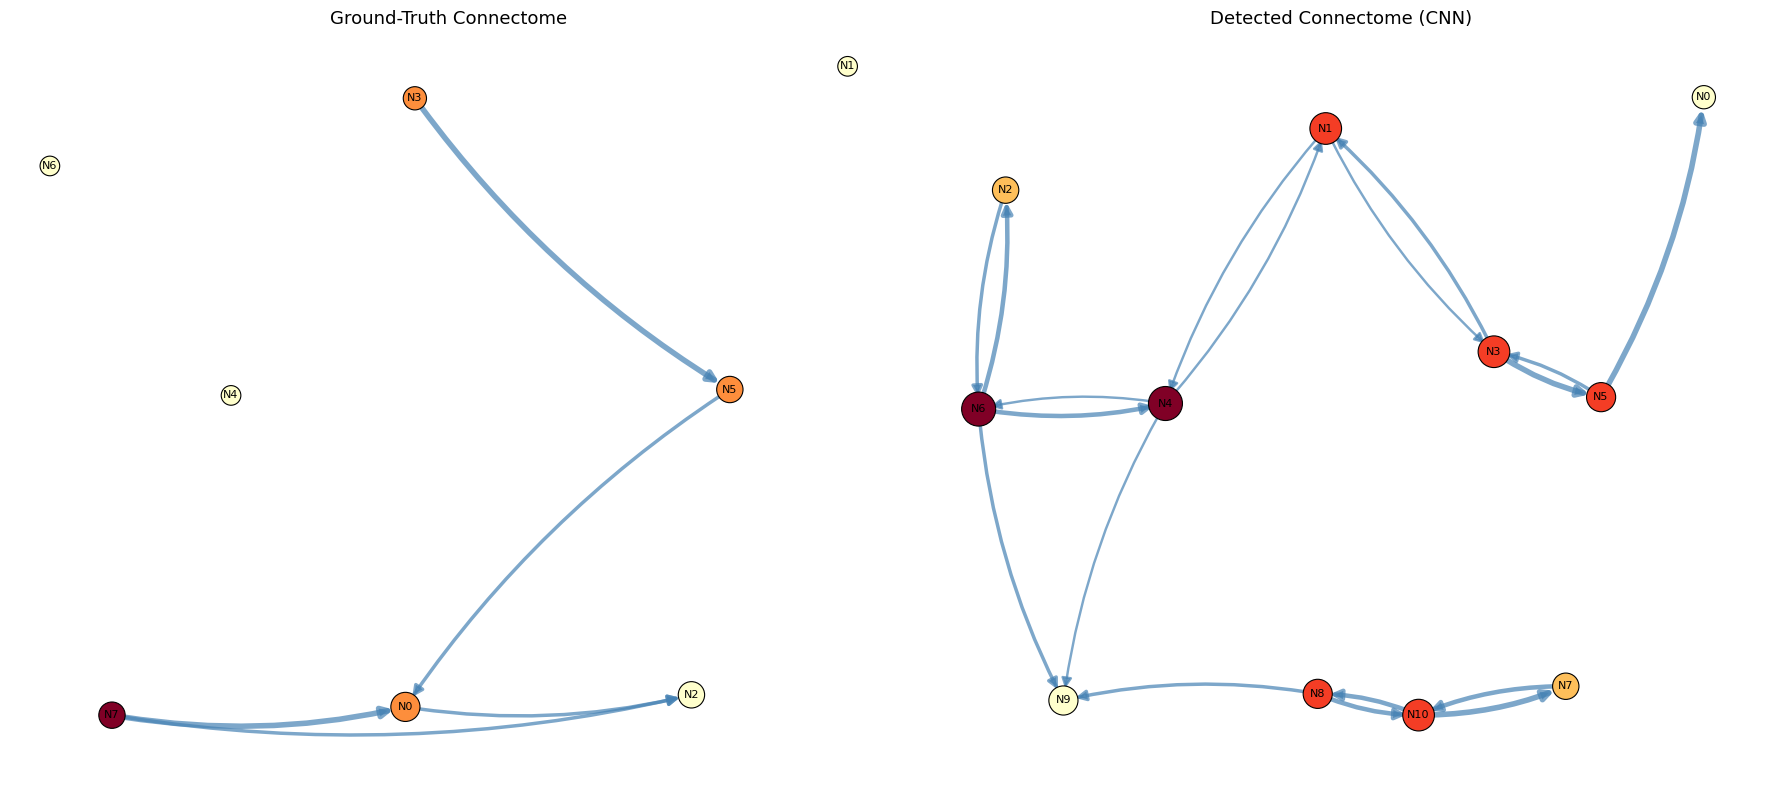

In [4]:
def draw_connectome(G, title='Connectome', ax=None, use_spatial=True):
    """Draw a directed connectome graph with weighted edges."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # Node positions
    if use_spatial and 'pos' in list(G.nodes(data=True))[0][1]:
        pos = nx.get_node_attributes(G, 'pos')
    else:
        pos = nx.spring_layout(G, seed=42, k=2.0)

    # Node sizes scaled by total degree
    degrees = dict(G.degree())
    node_sizes = [200 + 80 * degrees.get(n, 0) for n in G.nodes()]

    # Edge widths scaled by weight
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w   = max(weights) if weights else 1
    edge_widths = [1.0 + 3.0 * w / max_w for w in weights]

    # Node colors by out-degree (red = hub sender)
    out_deg  = dict(G.out_degree())
    max_out  = max(out_deg.values()) if out_deg else 1
    node_colors = [cm.YlOrRd(out_deg.get(n, 0) / (max_out + 1e-8)) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=node_sizes, node_color=node_colors,
                           edgecolors='black', linewidths=0.8)

    nx.draw_networkx_edges(G, pos, ax=ax,
                           width=edge_widths,
                           edge_color='steelblue', alpha=0.7,
                           arrows=True, arrowsize=15,
                           connectionstyle='arc3,rad=0.1')

    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8, font_color='black')

    ax.set_title(title, fontsize=13)
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(18, 8))
draw_connectome(G_gt,       title='Ground-Truth Connectome',  ax=axes[0])
draw_connectome(G_detected, title='Detected Connectome (CNN)', ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Overlay Connectome on the Raw Image

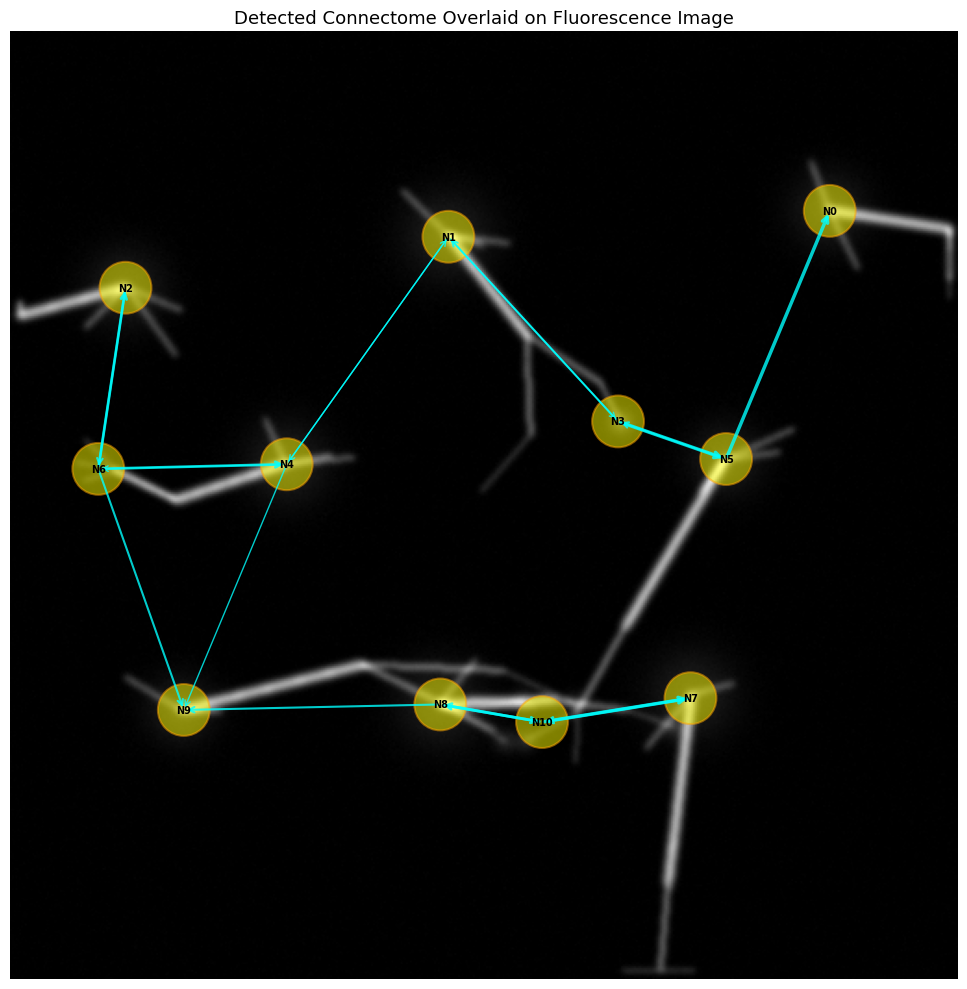

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image, cmap='gray', vmin=0, vmax=0.8)

# Draw detected connections as arrows on the image
for u, v, data in G_detected.edges(data=True):
    r0, c0 = detected_soma[u]
    r1, c1 = detected_soma[v]
    weight = data['weight']
    ax.annotate('', xy=(c1, r1), xytext=(c0, r0),
                arrowprops=dict(arrowstyle='->', color='cyan',
                                lw=0.5 + weight * 0.5, alpha=0.8))

# Draw soma circles
for i, (r, c) in enumerate(detected_soma):
    circle = plt.Circle((c, r), 14, fill=True, facecolor='yellow',
                         edgecolor='orange', alpha=0.5, linewidth=1.5)
    ax.add_patch(circle)
    ax.text(c, r, f'N{i}', ha='center', va='center', fontsize=7,
            color='black', fontweight='bold')

ax.set_title('Detected Connectome Overlaid on Fluorescence Image', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Graph Topology Analysis

In [6]:
def graph_summary(G, name):
    print(f'\n=== {name} ===')
    print(f'  Nodes                : {G.number_of_nodes()}')
    print(f'  Edges                : {G.number_of_edges()}')
    print(f'  Density              : {nx.density(G):.4f}')

    if G.number_of_edges() > 0:
        in_deg  = dict(G.in_degree())
        out_deg = dict(G.out_degree())
        print(f'  Avg in-degree        : {np.mean(list(in_deg.values())):.2f}')
        print(f'  Avg out-degree       : {np.mean(list(out_deg.values())):.2f}')
        print(f'  Max in-degree (hub)  : {max(in_deg.values())} (node {max(in_deg, key=in_deg.get)})')
        print(f'  Max out-degree (hub) : {max(out_deg.values())} (node {max(out_deg, key=out_deg.get)})')

    G_und = G.to_undirected()
    if nx.is_connected(G_und):
        print(f'  Avg shortest path    : {nx.average_shortest_path_length(G_und):.3f}')
        print(f'  Diameter             : {nx.diameter(G_und)}')
    else:
        largest = max(nx.connected_components(G_und), key=len)
        G_lcc   = G_und.subgraph(largest)
        print(f'  Largest CC size      : {len(largest)}')
        print(f'  Avg shortest path (LCC): {nx.average_shortest_path_length(G_lcc):.3f}')

    if nx.number_of_selfloops(G) == 0 and G.number_of_nodes() > 1:
        try:
            avg_clust = nx.average_clustering(G)
            print(f'  Avg clustering coeff : {avg_clust:.4f}')
        except Exception:
            pass


graph_summary(G_gt,       'Ground-Truth Connectome')
graph_summary(G_detected, 'Detected Connectome')


=== Ground-Truth Connectome ===
  Nodes                : 8
  Edges                : 5
  Density              : 0.0893
  Avg in-degree        : 0.62
  Avg out-degree       : 0.62
  Max in-degree (hub)  : 2 (node 0)
  Max out-degree (hub) : 2 (node 7)
  Largest CC size      : 5
  Avg shortest path (LCC): 1.700
  Avg clustering coeff : 0.1458

=== Detected Connectome ===
  Nodes                : 11
  Edges                : 18
  Density              : 0.1636
  Avg in-degree        : 1.64
  Avg out-degree       : 1.64
  Max in-degree (hub)  : 3 (node 9)
  Max out-degree (hub) : 3 (node 4)
  Avg shortest path    : 3.273
  Diameter             : 8
  Avg clustering coeff : 0.0530


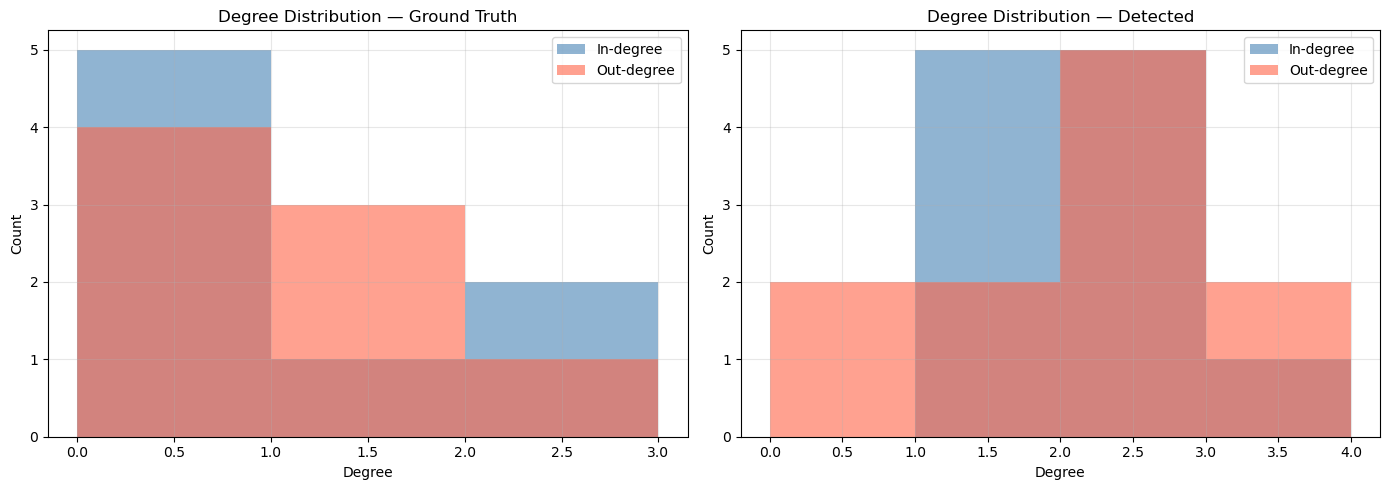

In [7]:
# Degree distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, G, title in [(axes[0], G_gt, 'Ground Truth'), (axes[1], G_detected, 'Detected')]:
    in_degs  = [d for _, d in G.in_degree()]
    out_degs = [d for _, d in G.out_degree()]
    bins = range(0, max(max(in_degs, default=0), max(out_degs, default=0)) + 2)
    ax.hist(in_degs,  bins=bins, alpha=0.6, label='In-degree',  color='steelblue')
    ax.hist(out_degs, bins=bins, alpha=0.6, label='Out-degree', color='tomato')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count')
    ax.set_title(f'Degree Distribution — {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Centrality analysis
if G_detected.number_of_edges() > 0:
    betweenness = nx.betweenness_centrality(G_detected, normalized=True)
    pagerank    = nx.pagerank(G_detected, alpha=0.85)
    in_degree_c = nx.in_degree_centrality(G_detected)

    centrality_df = pd.DataFrame({
        'Node'        : list(betweenness.keys()),
        'Betweenness' : [round(v, 4) for v in betweenness.values()],
        'PageRank'    : [round(v, 4) for v in pagerank.values()],
        'In-Degree'   : [round(v, 4) for v in in_degree_c.values()],
    }).sort_values('PageRank', ascending=False)

    print('Centrality rankings (detected connectome):')
    print(centrality_df.to_string(index=False))

Centrality rankings (detected connectome):
 Node  Betweenness  PageRank  In-Degree
   10       0.0333    0.1580        0.2
    6       0.1111    0.1040        0.2
    9       0.0000    0.1038        0.3
    7       0.0000    0.1036        0.1
    4       0.1889    0.0921        0.2
    8       0.0222    0.0844        0.1
    3       0.1444    0.0793        0.2
    1       0.1889    0.0754        0.2
    5       0.0556    0.0718        0.1
    0       0.0000    0.0676        0.1
    2       0.0000    0.0600        0.1


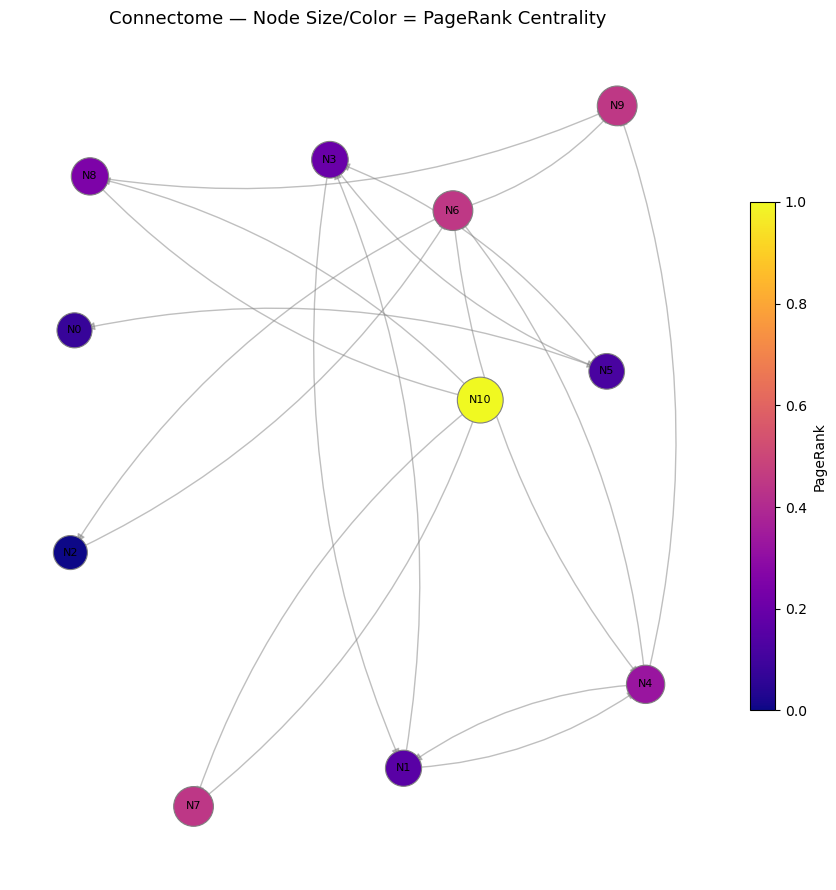

In [9]:
# Draw with PageRank-scaled nodes
if G_detected.number_of_edges() > 0:
    pos = nx.spring_layout(G_detected, seed=0, k=3.0)
    pr_vals = np.array([pagerank[n] for n in G_detected.nodes()])
    node_sizes = 300 + 5000 * pr_vals

    fig, ax = plt.subplots(figsize=(9, 9))
    sc = nx.draw_networkx_nodes(G_detected, pos, ax=ax,
                                node_size=node_sizes,
                                node_color=pr_vals, cmap='plasma',
                                edgecolors='gray', linewidths=0.8)
    nx.draw_networkx_edges(G_detected, pos, ax=ax,
                           edge_color='gray', alpha=0.5, arrows=True,
                           arrowsize=12, connectionstyle='arc3,rad=0.15')
    labels = {n: f'N{n}' for n in G_detected.nodes()}
    nx.draw_networkx_labels(G_detected, pos, labels, ax=ax, font_size=8)
    plt.colorbar(cm.ScalarMappable(cmap='plasma'), ax=ax, label='PageRank', shrink=0.6)
    ax.set_title('Connectome — Node Size/Color = PageRank Centrality', fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 6. Save Connectome Graphs for Notebook 4

In [10]:
connectome_data = {
    'G_gt'          : G_gt,
    'G_detected'    : G_detected,
    'detected_soma' : detected_soma,
    'gt_neurons'    : gt_neurons,
    'gt_synapses'   : gt_synapses,
    'image'         : image,
}

with open(DATA_DIR / 'connectome_graphs.pkl', 'wb') as f:
    pickle.dump(connectome_data, f)

print('Connectome graphs saved to data/connectome_graphs.pkl')

Connectome graphs saved to data/connectome_graphs.pkl


---

## Student Exercises

**Exercise 3.1** — The synapse-to-neuron assignment heuristic uses the *closest* soma as post-synaptic and the *second closest* as pre-synaptic. In reality, axon direction provides this information. What errors does this heuristic introduce? Compute the fraction of edges in `G_detected` that match the ground-truth edges in `G_gt`.

**Exercise 3.2** — Vary the `max_dist` threshold in `assign_synapses_to_neurons` from 40 to 120. Plot the number of edges in `G_detected` as a function of this threshold. What is the trade-off?

**Exercise 3.3** — Use `nx.community.greedy_modularity_communities(G_detected.to_undirected())` to detect communities. How many communities are found? Do they correspond to spatially clustered neurons in the image?

**Exercise 3.4** — Is the detected connectome a **small-world network**? Calculate the clustering coefficient and average path length. Compare these values to those of a random graph with the same number of nodes and edges (`nx.gnm_random_graph`). A network is small-world if clustering >> random and path length ≈ random.

**Exercise 3.5 (Challenge)** — Implement a function `connectome_precision_recall(G_detected, G_gt)` that computes the fraction of detected edges that are in the ground truth (precision) and the fraction of ground-truth edges that were detected (recall). Report results and discuss sources of error.